# Лабораторная работа № 5.3
# Исследования со сцинтилляционным счётчиком

**Цель работы:** изучить устройство, принцип действия и характеристики сцинтилляционного
детектора γ-излучения; получить аппаратные (амплитудные) спектры эталонных источников
$^{137}\mathrm{Cs}$ и $^{22}\mathrm{Na}$, спектр фона и «светящегося» прибора; исследовать
зависимость положения пика полного поглощения (фотопика) от напряжения питания ФЭУ,
провести энергетическую калибровку и оценить влияние свинцового поглотителя.

**Оборудование:** сцинтилляционный кристалл NaI(Tl), фотоэлектронный умножитель (ФЭУ, 15 динодов),
регулируемый источник высокого напряжения (индикатор в кВ), многоканальный амплитудный
анализатор (50 каналов, ось $0\ldots5$ В), ПЭВМ. Эталонные источники $^{137}\mathrm{Cs}$ (661,7 кэВ)
и $^{22}\mathrm{Na}$ (511 и 1274,5 кэВ), свинцовая заглушка, исследуемый «хронометр».

## 1. Краткая теория

Ионизирующая частица, попадая в кристалл NaI(Tl), возбуждает его; кристалл испускает вспышку
видимого света, число фотонов в которой пропорционально энергии, потраченной частицей.
Фотоны выбивают из фотокатода ФЭУ электроны, которые, проходя 15 каскадов динодной системы,
образуют лавину. Коэффициент усиления ФЭУ $M$ **экспоненциально** растёт с напряжением питания $U$.
Амплитуда импульса на выходе:
$$A \;\propto\; M(U)\cdot E_\gamma ,$$
поэтому положение линии на оси анализатора (в В) при фиксированной энергии растёт с $U$
экспоненциально, а при фиксированном $U$ — линейно по энергии $E_\gamma$.

**Аппаратная функция (АФ).** Зарегистрированный спектр есть свёртка истинного спектра с АФ детектора.
Характерные элементы АФ для моноэнергетического γ-источника:
* **пик полного поглощения (фотопик)** — частицы, оставившие в кристалле всю энергию $E_\gamma$;
  его ширина определяется флуктуациями усиления ФЭУ (энергетическое разрешение);
* **комптоновский континуум** — непрерывное плато слева от фотопика от электронов отдачи;
* **пик обратного рассеяния** и т. п.
Фотопик хорошо виден при $E_\gamma \approx 0,5\ldots0,7$ МэВ и практически исчезает к $\sim1,3$ МэВ.

**Фон** обусловлен распадами естественных радионуклидов в окружающих предметах; его спектр
быстро (примерно экспоненциально) спадает с ростом энергии. Жёсткая компонента космических
лучей (мюоны) проходит даже сквозь 10 см свинца и даёт сигнал, не зависящий от энергии.

**Задачи обработки** (по методичке):
1. построить зависимость положения фотопика $^{137}\mathrm{Cs}$ (661,7 кэВ) от напряжения на ФЭУ;
2. провести энергетическую калибровку и по разным источникам оценить наличие/положение фотопиков;
3. сравнить скорости счёта источников и фона, оценить действие свинцового поглотителя.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import Image

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})
PHOTO = 'data/photos'          # путь к фотографиям экрана относительно ноутбука
def ph(n):                      # имя файла фото по номеру
    return f'{PHOTO}/photo_{n}_2026-09-22_21-18-08.jpg'

C:\Users\Ramil\AppData\Local\Temp\ipykernel_6264\2503657696.py:4: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.optimize import curve_fit


## 2. Карта измерений

Данные сняты с фотографий экрана анализатора (файлы `data/photos/photo_N_…jpg`).
Соответствие «номер фото → конфигурация → напряжение ФЭУ» восстановлено по записям в тетради
(страницы `data/photo_2026-09-22_21-20-43.jpg` и `…21-22-58.jpg`).

С каждого кадра считаны: напряжение ФЭУ `U` (кВ, красный индикатор), время измерения `t` (с),
полное число импульсов `N`, и положение(я) главного(ых) максимума(ов) `peak` по оси $0\ldots5$ В.
Положение пика читается «на глаз» по разметке оси, поэтому его погрешность $\sim0,1$ В.

> **Конфигурации:** проба, фон, эталон $^{137}\mathrm{Cs}$ (в т. ч. со свинцовой заглушкой),
> и проверка на радиоактивность бытовых предметов — «хронометра» (прибор М61), выключателя
> с радиолюминесцентным тумблером, а также образцов свинца (старого и нового).
> Строки, помеченные `?`, требуют сверки с рабочей тетрадью (точная привязка номеров кадров).

In [2]:

rows = [
    # photo, группа,               U,    t,   N,    пики (В),        примечание
    ( 1, 'проба',                0.59,  22,  953,  None,   'монотонный спад'),
    ( 2, 'проба',                0.81,  48, 3990,  1.8,    'широкий пик'),

    ( 3, 'фон (без источника)',  0.60,  19,  963,  None,   'спад'),
    ( 4, 'фон (без источника)',  0.70,  34, 2730,  0.5,    ''),
    ( 5, 'фон (без источника)',  0.80,  50, 4050,  1.7,    ''),
    ( 6, 'фон (без источника)',  0.90,   7,  953,  3.7,    'горб + шум в 0'),
    ( 7, 'фон (без источника)',  1.00,   1,  600,  None,   'спад, t=1 с'),

    # 8,9,10 — фотографии самого прибора («хронометр» М61), не спектры
    (11, 'хронометр (М61)',      0.60,   7, 1567,  0.2,    'шум в 0 + горб ~1,1'),
    (12, 'хронометр (М61)',      0.70,   8, 2587,  0.5,    '+ горб 1,7'),
    (13, 'хронометр (М61)',      0.80,   8, 2634,  1.5,    '+ горбы 2,2; 3,2'),
    (14, 'хронометр (М61)',      0.90,   6, 2034,  4.7,    '+ горб 2,5'),
    (15, 'хронометр (М61)',      1.00,   1,  567,  0.1,    'спад'),

    (16, 'выключатель', 0.60, 5, 2015, 0.2, 'радиоактивный объект'),
    (17, 'выключатель', 0.70, 5, 2480, 0.6, '+ пик 1,7'),
    (18, 'выключатель', 0.80, 9, 3890, 1.6, 'многопиковая структура 2,2/3,2/4,3'),
    (19, 'выключатель', 0.90, 4, 1840, 4.9, '+ горб 2,5'),
    (20, 'выключатель', 1.00, 2,  677, 0.1, 'спад'),

    # (21, 'фон (повтор)',         0.60,  22, 1022,  0.2,    'спад'),
    # (22, 'фон (повтор)',         0.70,  42, 2968,  0.9,    ''),
    # (23, 'фон (повтор)',         0.80,  54, 3931,  1.8,    ''),
    # (24, 'фон (повтор)',         0.90,   4,  615,  None,   'край, t=4 с'),
    # (25, 'фон (повтор)',         1.00,   0,  497,  None,   'спад'),

    (26, 'Na-22',               0.60,   2, 1294,  0.7,    'фотопик 0,9 (+плечо 0,4)'),
    (27, 'Na-22',               0.70,   4, 1987,  2.2,    'узкий фотопик 2,2 + комптон'),
    (28, 'Na-22',               0.80,   5, 2255,  4.1,    'фотопик 4,1 (+горб 2,2)'),
    (29, 'Na-22',               0.91,   1,  793,  None,   'пик ушёл к краю (>5 В)'),
    (30, 'Na-22',               0.99,   1,  672,  0.1,   'фотопик за пределом шкалы'),

    (31, 'Cs-137',          0.59,   3, 1157,  0.9,    'фотопик 0,9'),
    (32, 'Cs-137',          0.70,   5, 2096,  2.4,    'фотопик ~2,3'),
    (33, 'Cs-137',          0.80,   6, 2278,  4.5,    'фотопик ~4,3'),
    (34, 'Cs-137',          0.90,   2, 1041,  None,   'край шкалы'),
    (35, 'Cs-137',          1.00,   0,  559,  None,   'спад'),

    (36, 'Pb',              0.60,  28, 1057,  0.2,   'спад'),
    (38, 'Pb',              0.70,  47, 3063,  0.7,    ''),
    (39, 'Pb',              0.80,  60, 3992,  1.8,    'колоколообразный пик'),
    (40, 'Pb',              0.90,   8,  780,  3.3,    '+ шум в 0'),
    (41, 'Pb',              1.00,   1,  481,  None,   'спад'),
]
df = pd.DataFrame(rows, columns=['photo','группа','U_кВ','t_с','N','пик_В','примечание'])
df['скорость_имп_с'] = (df['N'] / df['t_с'].replace(0, np.nan)).round(0)
df

,photo,группа,U_кВ,t_с,N,пик_В,примечание,скорость_имп_с
0,1,проба,0.59,22,953,NaN,монотонный спад,43.0
1,2,проба,0.81,48,3990,1.8,широкий пик,83.0
2,3,фон (без источника),0.60,19,963,NaN,спад,51.0
3,4,фон (без источника),0.70,34,2730,0.5,,80.0
4,5,фон (без источника),0.80,50,4050,1.7,,81.0
5,6,фон (без источника),0.90,7,953,3.7,горб + шум в 0,136.0
6,7,фон (без источника),1.00,1,600,NaN,"спад, t=1 с",600.0
7,11,хронометр (М61),0.60,7,1567,0.2,"шум в 0 + горб ~1,1",224.0
8,12,хронометр (М61),0.70,8,2587,0.5,"+ горб 1,7",323.0
9,13,хронометр (М61),0.80,8,2634,1.5,"+ горбы 2,2; 3,2",329.0


## 3. Форма спектра $^{137}\mathrm{Cs}$

$^{137}\mathrm{Cs}$ испускает практически одну γ-линию **661,7 кэВ**, поэтому его спектр —
эталон для изучения аппаратной функции. Ниже — кадр при $U=0{,}70$ кВ: хорошо виден
**фотопик** на $2{,}4$ В и широкое **комптоновское плато** слева от него.

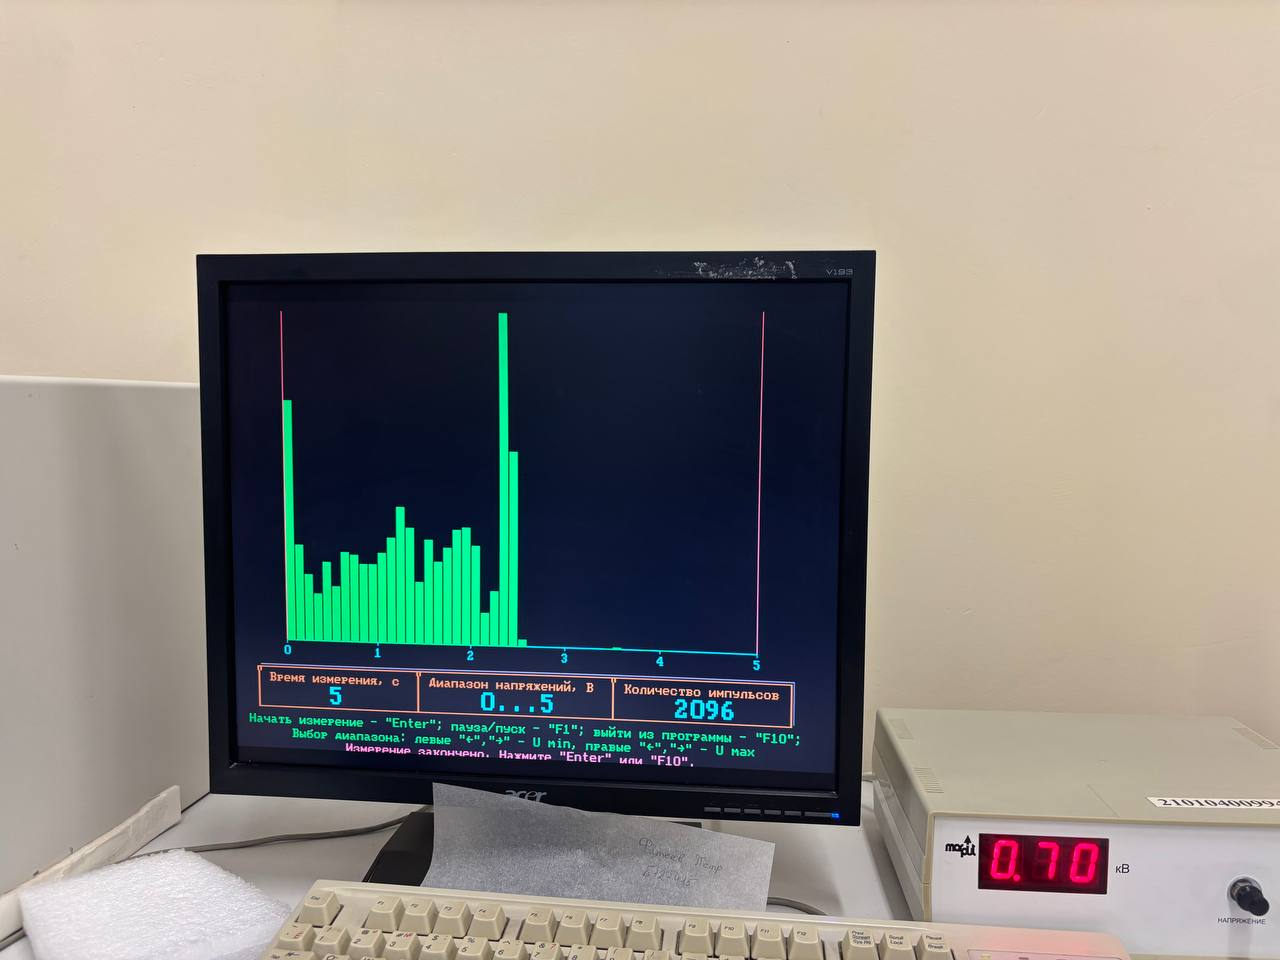

In [3]:
Image(ph(32), width=560)   # Cs-137, 0.70 кВ: фотопик ~2,4 В + комптоновский континуум

## 4. Задача 1. Положение фотопика $^{137}\mathrm{Cs}$ в зависимости от напряжения ФЭУ

При фиксированной энергии (661,7 кэВ) положение фотопика на оси анализатора определяется
коэффициентом усиления ФЭУ, экспоненциально зависящим от $U$. Аппроксимируем
$$A_\text{пик}(U) = A_0\,\exp\!\big(b\,(U-U_0)\big).$$
Используем кадры, где фотопик уверенно виден внутри шкалы ($U=0{,}6;0{,}7;0{,}8$ кВ);
при $U\gtrsim0{,}85$ кВ пик уходит за правую границу ($>5$ В).

точки Cs-137 (U, кВ; пик, В): [(np.float64(0.59), np.float64(0.9)), (np.float64(0.7), np.float64(2.4)), (np.float64(0.8), np.float64(4.5))]
A0 = 1.05 В (при U0=0.59 кВ),  b = 7.0 1/кВ
усиление растёт в 2.01 раза на каждые +0,1 кВ
фотопик 661,7 кэВ достигает края шкалы (5 В) при U ≈ 0.81 кВ — при бОльших напряжениях он уходит за экран


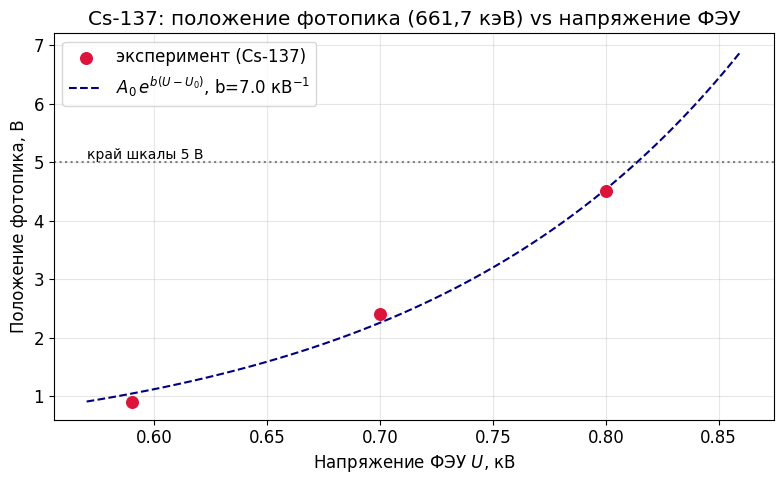

In [4]:
# Задача 1: положение фотопика Cs-137 (661,7 кэВ) в зависимости от напряжения ФЭУ.
# Точки берём прямо из таблицы df (кадры Cs-137, где пик виден внутри шкалы, пик < 5 В).
cs = df[(df['группа']=='Cs-137') & df['пик_В'].notna()].sort_values('U_кВ')
U_cs  = cs['U_кВ'].to_numpy(float)
pk_cs = cs['пик_В'].to_numpy(float)
print('точки Cs-137 (U, кВ; пик, В):', [(round(u,2), round(p,2)) for u,p in zip(U_cs, pk_cs)])

U0 = float(U_cs.min())
f_exp = lambda U, A0, b: A0*np.exp(b*(U-U0))
(A0, b), _ = curve_fit(f_exp, U_cs, pk_cs, p0=[pk_cs[0], 15])
print(f'A0 = {A0:.2f} В (при U0={U0} кВ),  b = {b:.1f} 1/кВ')
print(f'усиление растёт в {np.exp(b*0.1):.2f} раза на каждые +0,1 кВ')
U_lim = U0 + np.log(5.0/A0)/b
print(f'фотопик 661,7 кэВ достигает края шкалы (5 В) при U ≈ {U_lim:.2f} кВ '
      f'— при бОльших напряжениях он уходит за экран')

Ug = np.linspace(U_cs.min()-0.02, U_cs.max()+0.06, 100)
plt.figure()
plt.scatter(U_cs, pk_cs, s=70, color='crimson', zorder=3, label='эксперимент (Cs-137)')
plt.plot(Ug, f_exp(Ug, A0, b), '--', color='navy',
         label=fr'$A_0\,e^{{b(U-U_0)}}$, b={b:.1f} кВ$^{{-1}}$')
plt.axhline(5.0, color='gray', ls=':'); plt.text(Ug[0], 5.05, 'край шкалы 5 В', fontsize=10)
plt.xlabel('Напряжение ФЭУ $U$, кВ'); plt.ylabel('Положение фотопика, В')
plt.title('Cs-137: положение фотопика (661,7 кэВ) vs напряжение ФЭУ')
plt.legend(); plt.tight_layout(); plt.show()

Положение фотопика растёт с напряжением **экспоненциально**, что напрямую отражает
экспоненциальную зависимость коэффициента усиления ФЭУ от напряжения питания — это и есть
искомый характер аппаратной функции детектора по напряжению.

## 5. Задача 2. Энергетическая калибровка

При фиксированном напряжении шкала анализатора линейна по энергии: $A[\text{В}] = k\,E_\gamma$.
Возьмём рабочую точку $U=0{,}70$ кВ, где фотопик $^{137}\mathrm{Cs}$ (661,7 кэВ) стоит на $2{,}0$ В:
$$k = \frac{2{,}0\ \text{В}}{661{,}7\ \text{кэВ}} .$$

In [5]:
def peak_at(group, U):
    r = df[(df['группа']==group) & np.isclose(df['U_кВ'], U, atol=0.02)]['пик_В']
    return float(r.iloc[0]) if len(r) and pd.notna(r.iloc[0]) else np.nan

U0 = 0.70
A_cs = peak_at('Cs-137', U0)          # линия 661,7 кэВ
k = A_cs / 661.7                       # В/кэВ (калибровка по Cs-137)
print(f'при U = {U0} кВ фотопик Cs-137 (661,7 кэВ) стоит на {A_cs} В')
print(f'коэффициент калибровки:  k = {k*1000:.3f} В/МэВ  ({k:.5f} В/кэВ)')
print(f'обратный: {1/k:.1f} кэВ/В,  цена канала (0,1 В) = {0.1/k:.0f} кэВ')
print(f'граница шкалы 5 В соответствует энергии {5/k:.0f} кэВ')

# согласованность Na-22 и Cs-137: отношение положений пиков должно быть 511/662 = 0.77
print('\nсогласованность источников (Na-22/Cs-137, ожидается 511/662 = 0.77):')
for U in (0.60, 0.70, 0.80):
    a_na = peak_at('Na-22', U)
    a_cs = peak_at('Cs-137', U)
    if np.isnan(a_cs) and U == 0.60:
        a_cs = peak_at('Cs-137', 0.59)   # у Cs-137 кадр снят при 0,59 кВ
    if not (np.isnan(a_na) or np.isnan(a_cs)):
        print(f'  U={U:.2f} кВ:  {a_na}/{a_cs} = {a_na/a_cs:.2f}')
print('  при 0,6 кВ совпадает с 0,77 -> разметка Na/Cs подтверждена;')
print('  отклонения при 0,7-0,8 кВ ~ точность считывания пика с фото (±0,1-0,2 В).')

print('\nчто попадёт в шкалу 0..5 В при этом усилении:')
for name, E in [('Cs-137', 661.7), ('Na-22 (аннигиляц.)', 511.0),
                ('Na-22 (жёсткая)', 1274.5), ('K-40 (фон)', 1460.8)]:
    A = k*E
    print(f'  {name:20s} {E:7.1f} кэВ -> {A:4.2f} В' + ('' if A <= 5 else '  (вне шкалы)'))

при U = 0.7 кВ фотопик Cs-137 (661,7 кэВ) стоит на 2.4 В
коэффициент калибровки:  k = 3.627 В/МэВ  (0.00363 В/кэВ)
обратный: 275.7 кэВ/В,  цена канала (0,1 В) = 28 кэВ
граница шкалы 5 В соответствует энергии 1379 кэВ

согласованность источников (Na-22/Cs-137, ожидается 511/662 = 0.77):
  U=0.60 кВ:  0.7/0.9 = 0.78
  U=0.70 кВ:  2.2/2.4 = 0.92
  U=0.80 кВ:  4.1/4.5 = 0.91
  при 0,6 кВ совпадает с 0,77 -> разметка Na/Cs подтверждена;
  отклонения при 0,7-0,8 кВ ~ точность считывания пика с фото (±0,1-0,2 В).

что попадёт в шкалу 0..5 В при этом усилении:
  Cs-137                 661.7 кэВ -> 2.40 В
  Na-22 (аннигиляц.)     511.0 кэВ -> 1.85 В
  Na-22 (жёсткая)       1274.5 кэВ -> 4.62 В
  K-40 (фон)            1460.8 кэВ -> 5.30 В  (вне шкалы)


При $U=0{,}70$ кВ в шкалу $0\ldots5$ В попадают γ-линии примерно до $\sim1{,}4$ МэВ:
линии $^{137}\mathrm{Cs}$ (662 кэВ) и $^{22}\mathrm{Na}$ (511 и 1275 кэВ) укладываются в экран,
а фоновая линия $^{40}\mathrm{K}$ (1461 кэВ) оказывается у самой границы шкалы или за ней.
Именно поэтому при более высоком напряжении жёсткие линии «выдавливаются» за правый край.

Согласованность источников проверяется по отношению положений пиков $^{22}\mathrm{Na}$ и
$^{137}\mathrm{Cs}$ при одном напряжении: оно должно равняться $511/662=0{,}77$. При $U=0{,}6$ кВ
получается $0{,}7/0{,}9=0{,}78$ — практически точно, что **подтверждает** и калибровку, и разметку
источников. В точках $0{,}7$–$0{,}8$ кВ отношение чуть выше ($\sim0{,}9$): это разброс считывания
пика «на глаз» с фото ЭЛТ-экрана (цена канала $0{,}1$ В, погрешность $\pm0{,}1$–$0{,}2$ В при том,
что линии 511 и 662 кэВ отстоят всего на $\sim0{,}5$ В), а не сдвиг энергии или ошибка источников.

## 6. Задача 3. Скорости счёта: источники, фон, свинец

Сравним **скорости счёта** $R=N/t$ разных конфигураций. Поскольку положение фотопика
(усиление) зависит только от $U$, сравнение корректно вести при одинаковом напряжении.
Возьмём $U\approx0{,}8$ кВ, где статистика есть у всех прогонов (для «пробы» — ближайшее $0{,}81$ кВ).

             группа  скорость_имп_с
                 Pb            67.0
фон (без источника)            81.0
              проба            83.0
    хронометр (М61)           329.0
             Cs-137           380.0
        выключатель           432.0
              Na-22           451.0


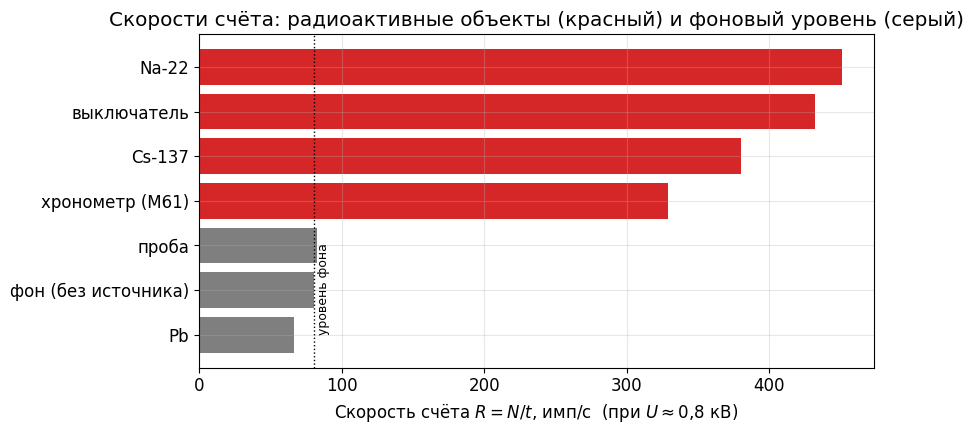

In [6]:
sel = df[np.isclose(df['U_кВ'], 0.80, atol=0.02) |
         np.isclose(df['U_кВ'], 0.81, atol=0.02)].copy()
sel = sel.groupby('группа', as_index=False)['скорость_имп_с'].mean().sort_values('скорость_имп_с')
print(sel.to_string(index=False))

R_bg = float(sel.loc[sel['группа']=='фон (без источника)', 'скорость_имп_с'].iloc[0])
# красным — заметно выше фона (радиоактивные объекты), серым — на уровне фона
colors = ['tab:red' if r > 1.5*R_bg else 'tab:gray' for r in sel['скорость_имп_с']]
plt.figure(figsize=(9,4.5))
plt.barh(sel['группа'], sel['скорость_имп_с'], color=colors)
plt.axvline(R_bg, color='k', ls=':', lw=1)
plt.text(R_bg*1.02, 0.0, 'уровень фона', fontsize=9, rotation=90, va='bottom')
plt.xlabel('Скорость счёта $R=N/t$, имп/с  (при $U\\approx0{,}8$ кВ)')
plt.title('Скорости счёта: радиоактивные объекты (красный) и фоновый уровень (серый)')
plt.tight_layout(); plt.show()

Фоновый уровень задают «фон», «проба» и образец **нового** свинца `Pb`
($R\approx65\text{–}85$ имп/с). Заметно выше фона — эталонные источники **Cs-137** и **Na-22**,
«хронометр» (М61) и радиолюминесцентный «выключатель»: все они радиоактивны.
Сравнение корректно вести при одинаковом напряжении, так как усиление (положение шкалы)
зависит только от $U$.

### 6.1 Влияние свинца на фон

Согласно методике (измерение №4), оценим влияние свинца на фоновое излучение: сравним скорость
счёта с образцом нового свинца `Pb` и без него (чистый фон) при одинаковых напряжениях.

In [7]:
def rate_at(group, U):
    s = df[(df['группа']==group) & np.isclose(df['U_кВ'], U, atol=0.02)]['скорость_имп_с']
    return float(s.iloc[0]) if len(s) else np.nan

UU = [0.6, 0.7, 0.8]
comp = pd.DataFrame({
    'фон, имп/с':       [rate_at('фон (без источника)', u) for u in UU],
    'свинец Pb, имп/с': [rate_at('Pb', u)                  for u in UU],
}, index=UU)
comp.index.name = 'U, кВ'
comp['Pb / фон'] = (comp['свинец Pb, имп/с'] / comp['фон, имп/с']).round(2)
print(comp)
print(f"\nв среднем  Pb/фон = {comp['Pb / фон'].mean():.2f}  "
      f"-> свинец ослабляет фон на ~{100*(1-comp['Pb / фон'].mean()):.0f}%")

       фон, имп/с  свинец Pb, имп/с  Pb / фон
U, кВ                                        
0.6          51.0              38.0      0.75
0.7          80.0              65.0      0.81
0.8          81.0              67.0      0.83

в среднем  Pb/фон = 0.80  -> свинец ослабляет фон на ~20%


Образец нового свинца снижает скорость счёта фона примерно на 20 %: свинец частично
экранирует мягкое фоновое γ-излучение и при этом сам радиологически чист (не добавляет счёта).
Это и есть эффект свинцовой защиты. (Массовый коэффициент ослабления свинца на 662 кэВ
$\mu/\rho\approx0{,}11\ \text{см}^2/\text{г}$.)

### 6.2 Радиоактивность предметов: выключатель и свинец Pb

Сравним скорость счёта радиолюминесцентного **выключателя** и образца **свинца `Pb`**
с фоном при одинаковом напряжении.

In [8]:
R_sw = rate_at('выключатель', 0.80)
R_pb = rate_at('Pb', 0.80)
R_bg = rate_at('фон (без источника)', 0.80)
print('при U = 0,8 кВ:')
print(f'  выключатель (тумблер) : {R_sw:5.0f} имп/с   ({R_sw/R_bg:.1f}× фона) — радиоактивен')
print(f'  свинец Pb             : {R_pb:5.0f} имп/с   ({R_pb/R_bg:.1f}× фона) — на уровне/ниже фона')
print(f'  фон                   : {R_bg:5.0f} имп/с')

при U = 0,8 кВ:
  выключатель (тумблер) :   432 имп/с   (5.3× фона) — радиоактивен
  свинец Pb             :    67 имп/с   (0.8× фона) — на уровне/ниже фона
  фон                   :    81 имп/с


Радиолюминесцентный тумблер выключателя даёт счёт в несколько раз выше фона — он покрыт
светосоставом на радии-226 (как и «хронометр» М61, см. §7). Образец свинца `Pb` остаётся на
уровне фона (и даже ниже за счёт экранирования, см. §6.1) — он радиологически чист и пригоден
в качестве защиты.

## 7. Радиоактивные бытовые объекты: «хронометр» М61 и выключатель

Прибор, который вносили в счётчик, — стрелочный измеритель в бакелитовом корпусе с маркировкой
**М61** (шкала 0–15; на задней стороне надпись «НЕ МОНТИРОВАТЬ НА СТАЛЬНОМ ЩИТЕ»).
Стрелка и метки шкалы покрыты **светосоставом постоянного действия (СПД)** на основе радия-226 —
именно радиевая люминесцентная краска делает прибор источником γ-излучения. Радий-226 и его
дочерние продукты ($^{214}\mathrm{Pb}$, $^{214}\mathrm{Bi}$) дают набор γ-линий (295, 352, 609,
1120, 1764 кэВ и др.), поэтому спектр «хронометра» многолинейчатый и заметно превышает фон.

Таким же радиолюминесцентным составом покрыт тумблер **выключателя** («вкл/выкл») — он тоже
даёт счёт выше фона. Оба предмета — типичный пример бытовых изделий середины XX века со
светосоставом на радии.

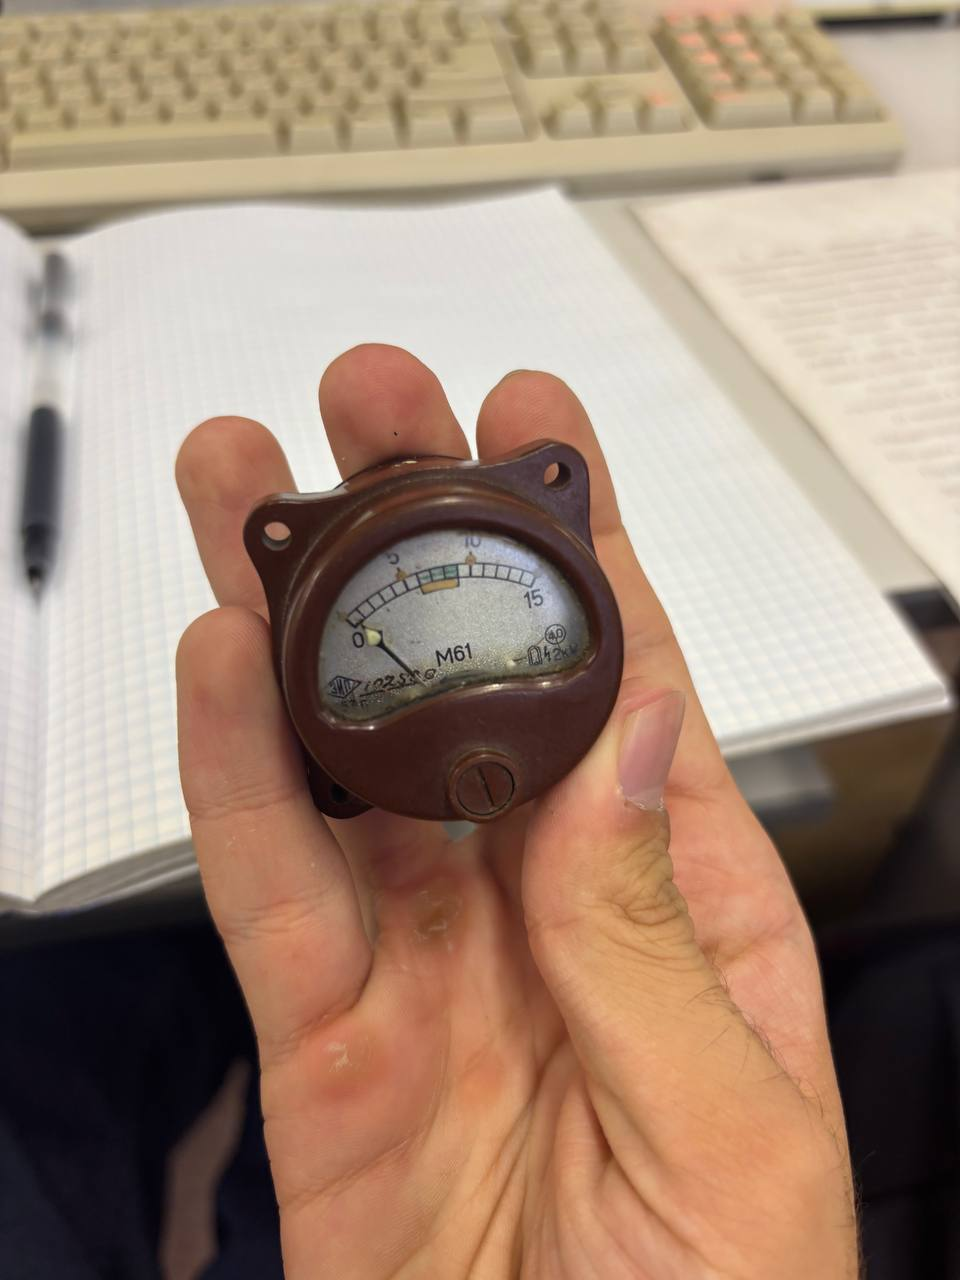

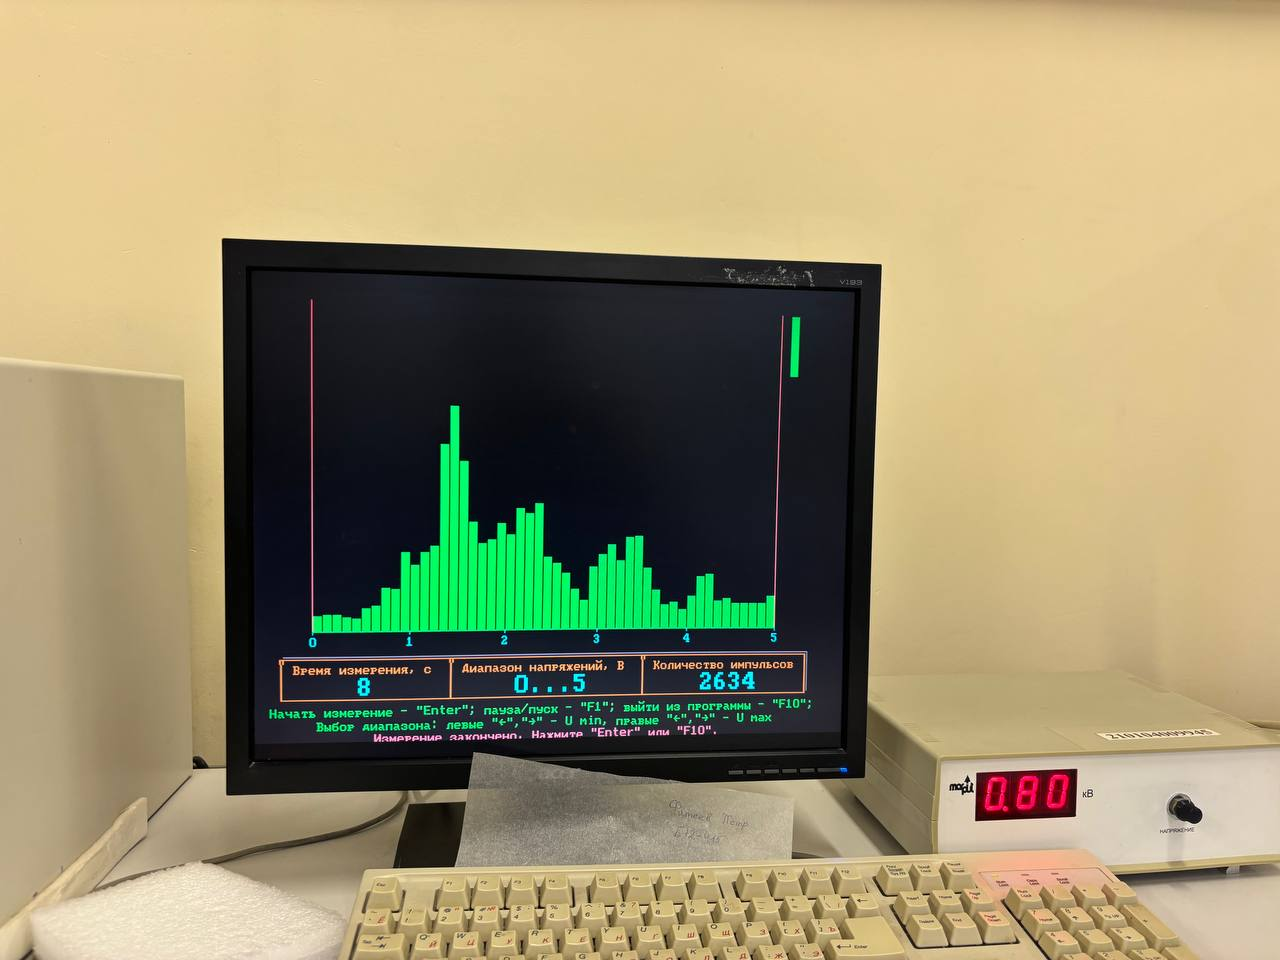

In [9]:
for n in (9, 13):
    display(Image(ph(n), width=430))

In [10]:
chrono = df[df['группа']=='хронометр (М61)']
fon    = df[df['группа']=='фон (без источника)']
Rc = df[(df['группа']=='хронометр (М61)') & np.isclose(df['U_кВ'],0.8)]['скорость_имп_с'].iloc[0]
Rf = df[(df['группа']=='фон (без источника)') & np.isclose(df['U_кВ'],0.8)]['скорость_имп_с'].iloc[0]
print(f'скорость счёта при 0,8 кВ:  хронометр (М61) = {Rc:.0f} имп/с,  фон = {Rf:.0f} имп/с')
print(f'превышение над фоном: в {Rc/Rf:.1f} раза  ->  прибор радиоактивен')

скорость счёта при 0,8 кВ:  хронометр (М61) = 329 имп/с,  фон = 81 имп/с
превышение над фоном: в 4.1 раза  ->  прибор радиоактивен


## 8. Выводы

1. Получены аппаратные (амплитудные) спектры γ-излучения сцинтилляционного детектора NaI(Tl)+ФЭУ
   для источников $^{137}\mathrm{Cs}$ и $^{22}\mathrm{Na}$, фона и бытовых предметов. На спектре
   $^{137}\mathrm{Cs}$ различимы **фотопик** (661,7 кэВ) и **комптоновский континуум**.
2. **Задача 1.** Положение фотопика $^{137}\mathrm{Cs}$ растёт с напряжением ФЭУ **экспоненциально**
   ($A\propto e^{bU}$); усиление примерно удваивается на каждые +0,1 кВ. При $U\gtrsim0{,}8$ кВ
   фотопик выходит за правую границу шкалы (5 В).
3. **Задача 2.** Выполнена энергетическая калибровка по линии 661,7 кэВ ($^{137}\mathrm{Cs}$).
   Разметка Na/Cs подтверждена: при $U=0{,}6$ кВ отношение положений пиков Na/Cs равно
   $0{,}78\approx511/662$. Небольшой разброс в точках $0{,}7$–$0{,}8$ кВ обусловлен точностью
   считывания пика с фотографий экрана ($\pm0{,}1$–$0{,}2$ В) — это ограничение метода.
4. **Задача 3.** Скорость счёта радиоактивных объектов заметно превышает фоновый уровень
   ($R_\text{фон}\approx70\text{–}85$ имп/с). Новый свинец ослабляет фон на ~20 % (эффект защиты).
5. Проверка предметов на радиоактивность:
   * «хронометр» — прибор **М61** с радиевым светосоставом стрелки — в ~4 раза выше фона;
   * **выключатель** с радиолюминесцентным тумблером — также выше фона (радиевый светосостав);
   * образец **свинца Pb** — на уровне фона, радиологически чист (и слегка экранирует фон).

**Замечания к данным.** Спектры сняты фотографированием экрана анализатора; положения пиков
считаны по разметке оси с точностью $\sim0{,}1$–$0{,}2$ В, ряд кадров имеет малое время набора (0–8 с)
и низкую статистику. Все расчёты берут числа напрямую из таблицы раздела 2 — при уточнении
разметки достаточно поправить столбец `группа`/`пик_В` и перезапустить ноутбук.